In [96]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time
import numpy as np
%matplotlib inline

In [97]:
# 展示高清图
from matplotlib_inline import backend_inline
backend_inline.set_matplotlib_formats('svg')

In [98]:
# 超参数
seed = 1145
batch_size = 256
epochs = 20
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
learning_rate = 1e-3
print(f"Using {device}")

Using cuda


In [99]:
torch.manual_seed(seed)

In [100]:
# 制作数据集

# 数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.1307, 0.3081)
])

train_dataset = datasets.MNIST(root='./datasets/mnist', 
                               train=True, 
                               download=True, 
                               transform=transform)
test_dataset = datasets.MNIST(root='./datasets/mnist', 
                              train=False, 
                              download=True, 
                              transform=transform)

from torch.utils.data import random_split

# 原始训练集 60000 张，切出 50000 训练、10000 验证
train_size = 50000
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
   
)


In [101]:
# 批次加载器
train_loader = DataLoader(dataset=train_subset, 
                          batch_size=batch_size, 
                          shuffle=True)     # 打乱数据
test_loader = DataLoader(dataset=test_dataset, 
                         batch_size=batch_size, 
                         shuffle=False)
val_loader = DataLoader(dataset=val_subset,
                        batch_size=batch_size,
                        shuffle=False)

In [102]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
        self.relu = nn.ReLU(inplace=True)

    def forward(self,x):
        out = self.bn1(self.conv1(x))
        return self.relu(out + self.shortcut(x))

In [103]:
class ResNet(nn.Module):
    def __init__(self):
        super(ResNet, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            ResBlock(64, 64),
            ResBlock(64, 128, stride=2),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(3),
            nn.Conv2d(128, 128, kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

In [104]:
# 查看网络结构
X = torch.rand(size=(1, 1, 28, 28))     # 随机生成测试图
for layer in ResNet().net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape: \t', X.shape)

Conv2d output shape: 	 torch.Size([1, 64, 14, 14])
BatchNorm2d output shape: 	 torch.Size([1, 64, 14, 14])
ResBlock output shape: 	 torch.Size([1, 64, 14, 14])
ResBlock output shape: 	 torch.Size([1, 128, 7, 7])
BatchNorm2d output shape: 	 torch.Size([1, 128, 7, 7])
MaxPool2d output shape: 	 torch.Size([1, 128, 2, 2])
Conv2d output shape: 	 torch.Size([1, 128, 1, 1])
Flatten output shape: 	 torch.Size([1, 128])
Linear output shape: 	 torch.Size([1, 10])


In [105]:
model = ResNet().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [106]:
# 预训练
# 每个数字取 2 张，共 20 张；始终训练同一批
indices = torch.cat([
    torch.where(train_dataset.targets == digit)[0][:2]
    for digit in range(10)
])
tiny_loader = DataLoader(
    torch.utils.data.Subset(train_dataset, indices.tolist()),
    batch_size=20
)
x, y = next(iter(tiny_loader))
x, y = x.to(device), y.to(device)
print(indices)

model.train()

for step in range(501):
    logits = model(x)
    loss = torch.nn.functional.cross_entropy(logits, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 100 == 0:
        acc = (logits.argmax(1) == y).float().mean().item()
        print(step, f"loss={loss.item():.4f}", f"accuracy={acc:.0%}")

tensor([ 1, 21,  3,  6,  5, 16,  7, 10,  2,  9,  0, 11, 13, 18, 15, 29, 17, 31,
         4, 19])
0 loss=2.5979 accuracy=5%
100 loss=0.3182 accuracy=100%
200 loss=0.1229 accuracy=100%
300 loss=0.0710 accuracy=100%
400 loss=0.0487 accuracy=100%
500 loss=0.0366 accuracy=100%


In [107]:
# 损失函数
loss_fn = nn.CrossEntropyLoss()

In [108]:
# 优化算法
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [109]:
# 训练网络
losses = []
epoch_losses = []
losses_val = []
best_epoch = -1
best_acc = 0
min_losses_val = float('inf')
accs = []
patience = 5
bad_epochs = 0
for epoch in range(epochs):
    start = time.time()
    model.train()
    epoch_loss = 0
    for (x,y) in train_loader:
        x,y = x.to(device),y.to(device)
        pred = model(x)
        loss = loss_fn(pred,y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        epoch_loss += loss.item()
    end = time.time()
    # 测试网络
    correct = 0
    total = 0
    model.eval()
    loss_val = 0
    with torch.no_grad():
        for data in val_loader:
            images, labels = data
            images,labels = images.to(device),labels.to(device)
            outputs = model(images)
            loss_val += loss_fn(outputs, labels)
            _, predicted = torch.max(outputs, 1)       # 索引/预测结果
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = correct / total
    avg_loss_val = loss_val.item() / len(val_loader)
    losses_val.append(avg_loss_val)
    epoch_losses.append(epoch_loss/len(train_loader))
    accs.append(acc)
    print('Epoch: %d, Loss: %.4f, Loss Val: %.4f, Accuracy: %.4f, Time: %.2f' % (epoch, epoch_losses[-1], avg_loss_val, acc, end - start))
    # 验证损失
    if avg_loss_val < min_losses_val:
        min_losses_val = avg_loss_val
        best_epoch = epoch
        torch.save(model.state_dict(), "models/ResNet_best_model.pth")
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch: 0, Loss: 0.2049, Loss Val: 0.0867, Accuracy: 0.9719, Time: 8.23
Epoch: 1, Loss: 0.0559, Loss Val: 0.0684, Accuracy: 0.9789, Time: 9.96
Epoch: 2, Loss: 0.0375, Loss Val: 0.0640, Accuracy: 0.9802, Time: 9.81
Epoch: 3, Loss: 0.0299, Loss Val: 0.0516, Accuracy: 0.9841, Time: 9.13
Epoch: 4, Loss: 0.0280, Loss Val: 0.0628, Accuracy: 0.9796, Time: 9.43
Epoch: 5, Loss: 0.0169, Loss Val: 0.0504, Accuracy: 0.9860, Time: 8.89
Epoch: 6, Loss: 0.0131, Loss Val: 0.0573, Accuracy: 0.9834, Time: 8.77
Epoch: 7, Loss: 0.0152, Loss Val: 0.0485, Accuracy: 0.9873, Time: 8.63
Epoch: 8, Loss: 0.0154, Loss Val: 0.0522, Accuracy: 0.9870, Time: 8.49
Epoch: 9, Loss: 0.0151, Loss Val: 0.0957, Accuracy: 0.9785, Time: 8.40
Epoch: 10, Loss: 0.0151, Loss Val: 0.0687, Accuracy: 0.9823, Time: 8.41
Epoch: 11, Loss: 0.0131, Loss Val: 0.0725, Accuracy: 0.9837, Time: 8.47
Epoch: 12, Loss: 0.0115, Loss Val: 0.0618, Accuracy: 0.9868, Time: 8.54
Early stopping at epoch 12


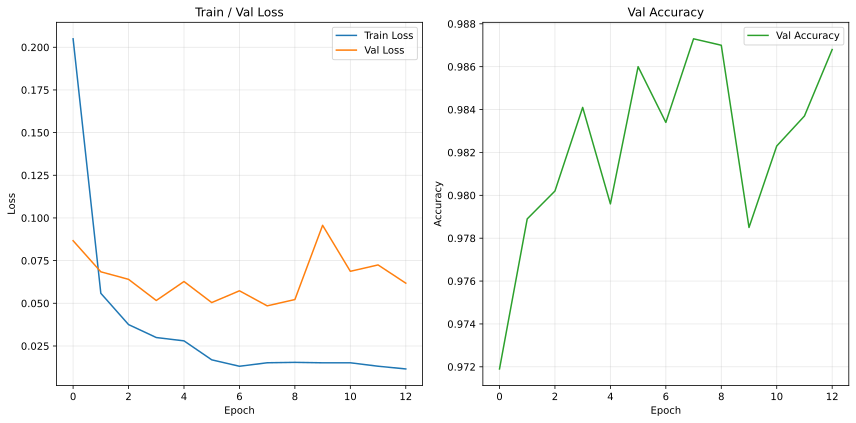

In [110]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ep = range(len(epoch_losses))

# 左图：训练损失 + 验证损失 放同一张图
ax[0].plot(ep, epoch_losses, label='Train Loss')
ax[0].plot(ep, losses_val,  label='Val Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Train / Val Loss')
ax[0].legend()
ax[0].grid(alpha=0.3)

# 右图：验证准确率
ax[1].plot(range(len(accs)), accs, label='Val Accuracy', color='tab:green')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Val Accuracy')
ax[1].legend()
ax[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

In [111]:
model.load_state_dict(torch.load("models/ResNet_best_model.pth"))
# 测试网络
correct = 0
total = 0
model.eval()
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        images,labels = images.to(device),labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)       # 索引/预测结果
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network: %.4f %%' % (
    100 * correct / total))

C:\Users\HONOR\AppData\Local\Temp\ipykernel_51184\94631959.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/ResNet_best_model.pth

Accuracy of the network: 98.7200 %
